# 📊 IFS-Analyse Dashboard — IBM i / AS400

**Erstellt für:** Vorstandspräsentation  
**Zweck:** Übersicht über den Inhalt des Integrated File System (IFS)  
**Datenquelle:** `scndir()`-Funktion via `os.scandir()` + `os.stat()`

---
> **Hinweis zur Nutzung:** Dieses Notebook erwartet einen Pandas-DataFrame `ef` mit den Spalten:  
> `Name`, `Path`, `Type`, `Inode`, `ID_Nbr`, `nbrLinks`, `UID`, `GrID`, `Size`, `MRAcc_Tme`, `MRMod_Tme`, `MRCr_Tme`  
> Bitte den eigenen DataFrame entsprechend einlesen oder die Zelle „Demo-Daten" für Tests verwenden.

## 0️⃣ Imports & Konfiguration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')

# ── Globale Plot-Einstellungen ──────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='Blues_d', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
CORP_BLUE   = '#003366'
CORP_ACCENT = '#0066CC'
CORP_LIGHT  = '#CCE0FF'
CORP_WARN   = '#FF6600'
CORP_OK     = '#009900'

print('✅ Imports erfolgreich. Pandas:', pd.__version__)

✅ Imports erfolgreich. Pandas: 2.2.2


## 1️⃣ Daten laden

Entweder den echten DataFrame aus der `scndir()`-Funktion einlesen **oder** die Demo-Daten aktivieren (Kommentar entfernen).

In [2]:
# ── Option A: Echte Daten aus CSV (von scndir erzeugt) ──────────────────────
# ef = pd.read_csv('/pfad/zum/ergebnis.csv', sep=';', encoding='utf-8')

# ── Option B: Demo-Daten (zum Testen des Notebooks) ────────────────────────
rng = np.random.default_rng(42)
n   = 2000
dirs = ['/home/user1', '/home/user2', '/QOpenSys/pkgs', '/QIBM/ProdData',
        '/QIBM/UserData', '/tmp', '/var/log', '/usr/local', '/opt/app', '/data/archive']
exts = ['csv','txt','xlsx','pdf','log','xml','json','py','sh','']
ext_w = [0.15,0.18,0.08,0.06,0.20,0.07,0.05,0.04,0.05,0.12]

names  = [f'file_{i}.{rng.choice(exts, p=ext_w)}' for i in range(n)]
paths  = [rng.choice(dirs) for _ in range(n)]
sizes  = rng.lognormal(mean=3, sigma=2.5, size=n).clip(0.001, 5000)  # MB

base   = datetime(2018, 1, 1).timestamp()
now    = datetime.now().timestamp()
cr_ts  = rng.uniform(base, now, n)
mod_ts = cr_ts + rng.uniform(0, 3*365*86400, n)
mod_ts = np.minimum(mod_ts, now)
acc_ts = mod_ts + rng.uniform(0, 180*86400, n)
acc_ts = np.minimum(acc_ts, now)

ef = pd.DataFrame({
    'Name'     : names,
    'Path'     : paths,
    'Size'     : sizes,
    'MRCr_Tme' : cr_ts,
    'MRMod_Tme': mod_ts,
    'MRAcc_Tme': acc_ts,
})
print(f'📂 Datensatz geladen: {len(ef):,} Dateien — Demo-Modus aktiv')

# ── Zeitstempel → datetime ──────────────────────────────────────────────────
for col in ['MRCr_Tme', 'MRMod_Tme', 'MRAcc_Tme']:
    if pd.api.types.is_numeric_dtype(ef[col]):
        ef[col] = pd.to_datetime(ef[col], unit='s', errors='coerce')

# ── Erweiterung ableiten ────────────────────────────────────────────────────
ef['ext'] = ef['Name'].apply(
    lambda x: x.split('.')[-1].lower() if len(x.split('.')) > 1 else '(kein)'
)

# ── Alter in Tagen (seit letzter Änderung) ──────────────────────────────────
ef['alter_tage'] = (pd.Timestamp.now() - ef['MRMod_Tme']).dt.days

ef.head(3)

📂 Datensatz geladen: 2,000 Dateien — Demo-Modus aktiv


,Name,Path,Size,MRCr_Tme,MRMod_Tme,MRAcc_Tme,ext,alter_tage
0,file_0.json,/QIBM/ProdData,281.734170,2024-09-20 07:26:09.501915455,2025-02-04 06:07:06.597578049,2025-07-04 18:34:53.742058039,json,413
1,file_1.pdf,/opt/app,3.040286,2020-04-05 07:45:52.274361610,2021-05-29 12:24:03.485430002,2021-11-12 14:21:44.378413439,pdf,1760
2,file_2.sh,/home/user1,0.021305,2022-07-09 09:14:01.262525320,2025-02-01 12:07:01.229932785,2025-05-27 01:59:05.794584751,sh,416


---
## 2️⃣ Kennzahlen-Übersicht (KPI-Tabelle)

Kurze Zusammenfassung der wichtigsten Metriken — ideal als erste Folie.

In [3]:
total_files  = len(ef)
total_gb     = ef['Size'].sum() / 1024
avg_mb       = ef['Size'].mean()
oldest_mod   = ef['MRMod_Tme'].min()
newest_mod   = ef['MRMod_Tme'].max()
inactive_3y  = (ef['alter_tage'] > 3*365).sum()
pct_inactive = inactive_3y / total_files * 100

print('=' * 55)
print('  IFS KENNZAHLEN-ÜBERSICHT')
print('=' * 55)
print(f'  Gesamtzahl Dateien          : {total_files:>10,}')
print(f'  Gesamtspeicher (GB)         : {total_gb:>10.2f}')
print(f'  Ø Dateigröße (MB)           : {avg_mb:>10.3f}')
print(f'  Älteste Änderung            : {oldest_mod:%d.%m.%Y}')
print(f'  Jüngste Änderung            : {newest_mod:%d.%m.%Y}')
print(f'  Inaktiv > 3 Jahre           : {inactive_3y:>10,}  ({pct_inactive:.1f}%)')
print('=' * 55)

  IFS KENNZAHLEN-ÜBERSICHT
  Gesamtzahl Dateien          :      2,000
  Gesamtspeicher (GB)         :     481.59
  Ø Dateigröße (MB)           :    246.574
  Älteste Änderung            : 20.02.2018
  Jüngste Änderung            : 24.03.2026
  Inaktiv > 3 Jahre           :        927  (46.4%)


---
## 3️⃣ Speicherverteilung nach Dateityp (Donut-Chart)

> **Kernaussage:** Welche Dateitypen belegen den meisten Speicher?

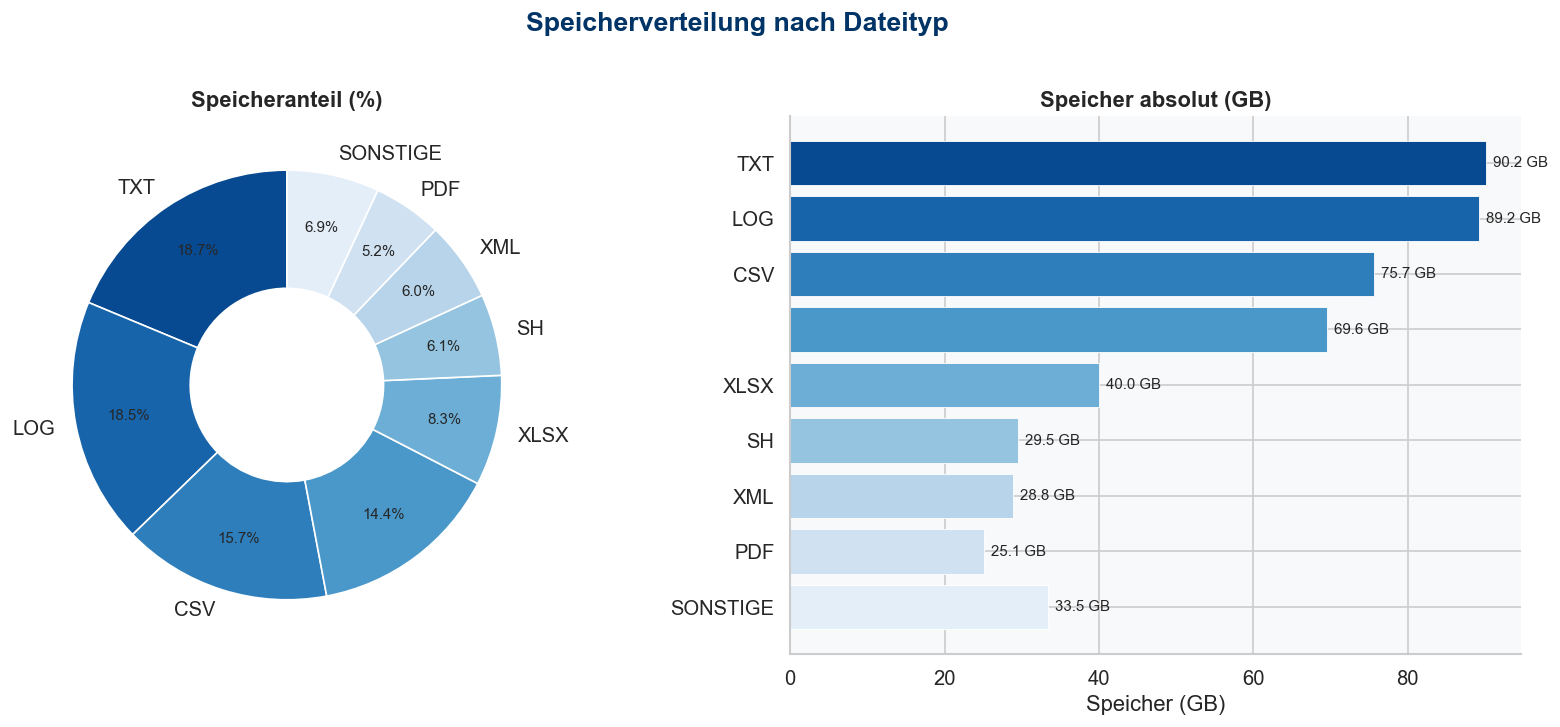

💾 Grafik gespeichert: ifs_speicher_dateityp.png


In [4]:
top_n   = 8
by_ext  = ef.groupby('ext')['Size'].sum().sort_values(ascending=False)
top_ext = by_ext.head(top_n)
other   = by_ext.iloc[top_n:].sum()
if other > 0:
    top_ext['Sonstige'] = other

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Speicherverteilung nach Dateityp', fontsize=16, fontweight='bold', color=CORP_BLUE, y=1.01)

# Donut
colors = sns.color_palette('Blues_r', len(top_ext))
wedges, texts, autotexts = axes[0].pie(
    top_ext.values,
    labels=top_ext.index.str.upper(),
    autopct='%1.1f%%',
    colors=colors,
    wedgeprops=dict(width=0.55),
    startangle=90,
    pctdistance=0.75,
)
for at in autotexts:
    at.set_fontsize(9)
axes[0].set_title('Speicheranteil (%)', fontweight='bold')

# Balkendiagramm daneben
bars = axes[1].barh(
    top_ext.index.str.upper()[::-1],
    (top_ext / 1024).values[::-1],
    color=colors[::-1],
    edgecolor='white', linewidth=0.5
)
axes[1].set_xlabel('Speicher (GB)')
axes[1].set_title('Speicher absolut (GB)', fontweight='bold')
for bar in bars:
    w = bar.get_width()
    axes[1].text(w + 0.01 * max((top_ext/1024).values),
                 bar.get_y() + bar.get_height()/2,
                 f'{w:.1f} GB', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('ifs_speicher_dateityp.png', bbox_inches='tight', dpi=150)
plt.show()
print('💾 Grafik gespeichert: ifs_speicher_dateityp.png')

---
## 4️⃣ Top-10 Verzeichnisse: Dateizahl & Speicher

> **Kernaussage:** Wo liegen die meisten/größten Dateien?

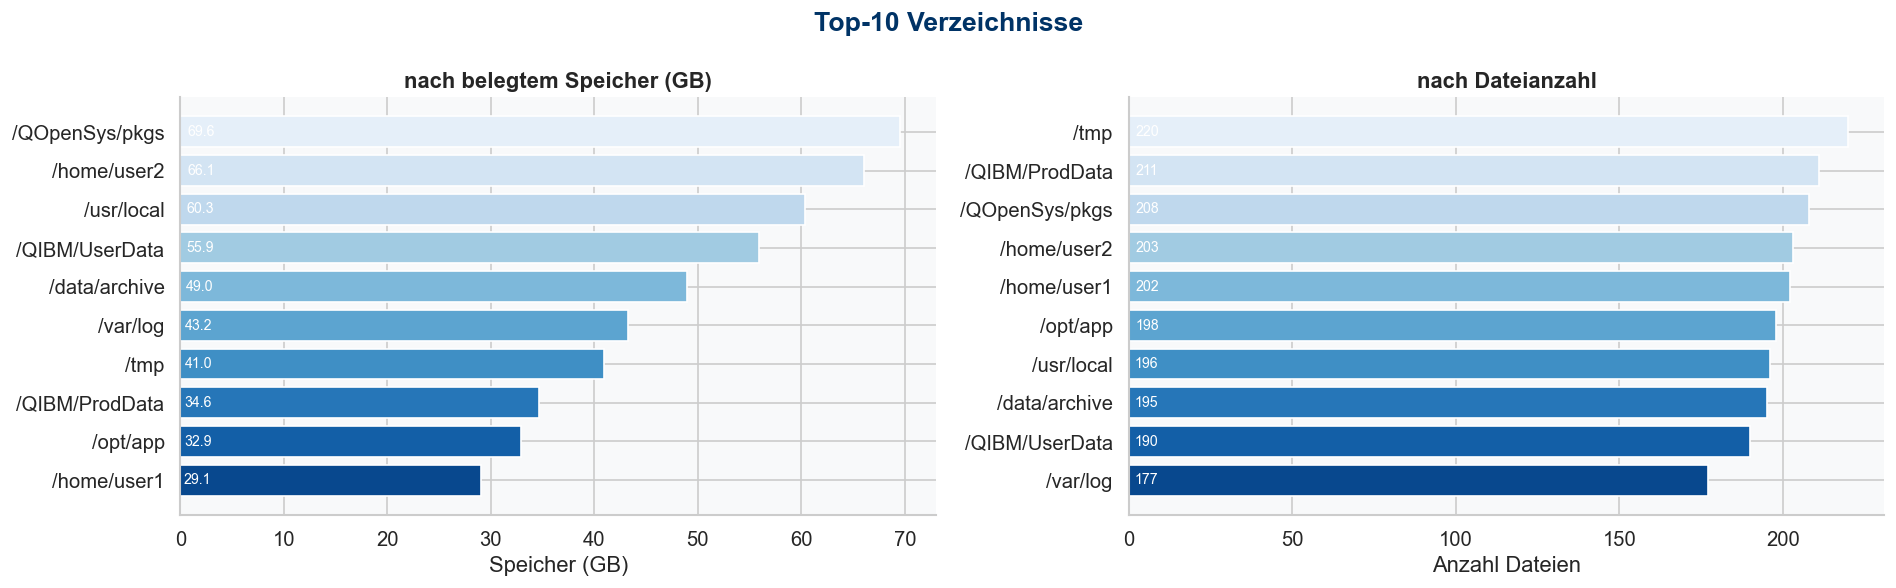

💾 Grafik gespeichert: ifs_top10_verzeichnisse.png


In [5]:
by_dir = ef.groupby('Path').agg(
    Anzahl=('Name', 'count'),
    Speicher_GB=('Size', lambda x: x.sum() / 1024)
).sort_values('Speicher_GB', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Top-10 Verzeichnisse', fontsize=16, fontweight='bold', color=CORP_BLUE)

pal = sns.color_palette('Blues_r', 10)

# Speicher
sorted_sp = by_dir.sort_values('Speicher_GB')
axes[0].barh(sorted_sp.index, sorted_sp['Speicher_GB'], color=pal, edgecolor='white')
axes[0].set_xlabel('Speicher (GB)')
axes[0].set_title('nach belegtem Speicher (GB)', fontweight='bold')
for i, (val, label) in enumerate(zip(sorted_sp['Speicher_GB'], sorted_sp.index)):
    axes[0].text(val * 0.01, i, f'{val:.1f}', va='center', fontsize=8.5, color='white' if val > sorted_sp['Speicher_GB'].max()*0.3 else CORP_BLUE)

# Dateianzahl
sorted_az = by_dir.sort_values('Anzahl')
axes[1].barh(sorted_az.index, sorted_az['Anzahl'], color=pal, edgecolor='white')
axes[1].set_xlabel('Anzahl Dateien')
axes[1].set_title('nach Dateianzahl', fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, val in enumerate(sorted_az['Anzahl']):
    axes[1].text(val * 0.01, i, f'{val:,}', va='center', fontsize=8.5, color='white' if val > sorted_az['Anzahl'].max()*0.3 else CORP_BLUE)

plt.tight_layout()
plt.savefig('ifs_top10_verzeichnisse.png', bbox_inches='tight', dpi=150)
plt.show()
print('💾 Grafik gespeichert: ifs_top10_verzeichnisse.png')

---
## 5️⃣ Treemap: Speicher nach Verzeichnis & Dateityp (Plotly)

> **Kernaussage:** Hierarchische Übersicht — ideal für interaktive Präsentationen.

In [6]:
tm_data = ef.groupby(['Path', 'ext'])['Size'].sum().reset_index()
tm_data['Size_GB'] = tm_data['Size'] / 1024
tm_data = tm_data[tm_data['Size_GB'] > 0.001]

fig_tm = px.treemap(
    tm_data,
    path=[px.Constant('IFS'), 'Path', 'ext'],
    values='Size_GB',
    color='Size_GB',
    color_continuous_scale='Blues',
    title='<b>IFS Speicherbelegung — Treemap</b><br><sup>Hierarchie: Verzeichnis → Dateityp | Fläche = Speicher (GB)</sup>',
    hover_data={'Size_GB': ':.2f'},
    labels={'Size_GB': 'Speicher (GB)'},
)
fig_tm.update_layout(
    margin=dict(t=80, l=10, r=10, b=10),
    coloraxis_colorbar=dict(title='GB'),
    height=600,
)
fig_tm.show()
fig_tm.write_html('ifs_treemap.html')
print('💾 Interaktive Treemap gespeichert: ifs_treemap.html')

💾 Interaktive Treemap gespeichert: ifs_treemap.html


---
## 6️⃣ Altersanalyse: Wie alt sind die Dateien?

> **Kernaussage:** Überblick über die "Frische" der Daten — zeigt Einsparpotenziale.

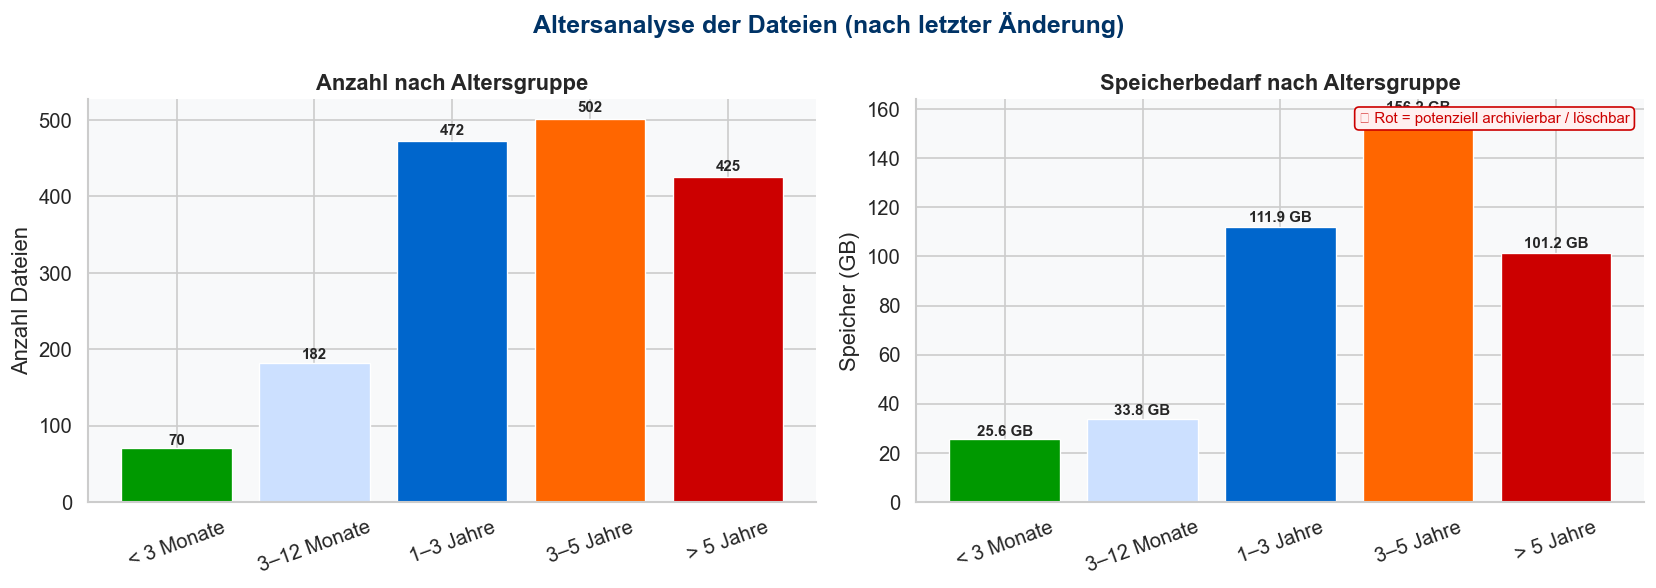

💾 Grafik gespeichert: ifs_altersanalyse.png


In [7]:
bins   = [0, 90, 365, 3*365, 5*365, np.inf]
labels = ['< 3 Monate', '3–12 Monate', '1–3 Jahre', '3–5 Jahre', '> 5 Jahre']
ef['altersgruppe'] = pd.cut(ef['alter_tage'], bins=bins, labels=labels)

age_cnt = ef.groupby('altersgruppe', observed=True).agg(
    Anzahl=('Name', 'count'),
    Speicher_GB=('Size', lambda x: x.sum() / 1024)
).reset_index()

farben = [CORP_OK, CORP_LIGHT, CORP_ACCENT, CORP_WARN, '#CC0000']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Altersanalyse der Dateien (nach letzter Änderung)',
             fontsize=15, fontweight='bold', color=CORP_BLUE)

bars1 = axes[0].bar(age_cnt['altersgruppe'], age_cnt['Anzahl'], color=farben, edgecolor='white', linewidth=0.8)
axes[0].set_ylabel('Anzahl Dateien')
axes[0].set_title('Anzahl nach Altersgruppe', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in bars1:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h * 1.01, f'{int(h):,}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

bars2 = axes[1].bar(age_cnt['altersgruppe'], age_cnt['Speicher_GB'], color=farben, edgecolor='white', linewidth=0.8)
axes[1].set_ylabel('Speicher (GB)')
axes[1].set_title('Speicherbedarf nach Altersgruppe', fontweight='bold')
for bar in bars2:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h * 1.01, f'{h:.1f} GB',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

for ax in axes:
    ax.tick_params(axis='x', rotation=20)

# Legende als Anmerkung
axes[1].annotate('🔴 Rot = potenziell archivierbar / löschbar',
                 xy=(0.98, 0.97), xycoords='axes fraction',
                 ha='right', va='top', fontsize=9, color='#CC0000',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF0F0', edgecolor='#CC0000'))

plt.tight_layout()
plt.savefig('ifs_altersanalyse.png', bbox_inches='tight', dpi=150)
plt.show()
print('💾 Grafik gespeichert: ifs_altersanalyse.png')

---
## 7️⃣ Heatmap: Datei-Aktivität nach Monat & Jahr

> **Kernaussage:** In welchen Zeiträumen wurde das IFS besonders stark genutzt?

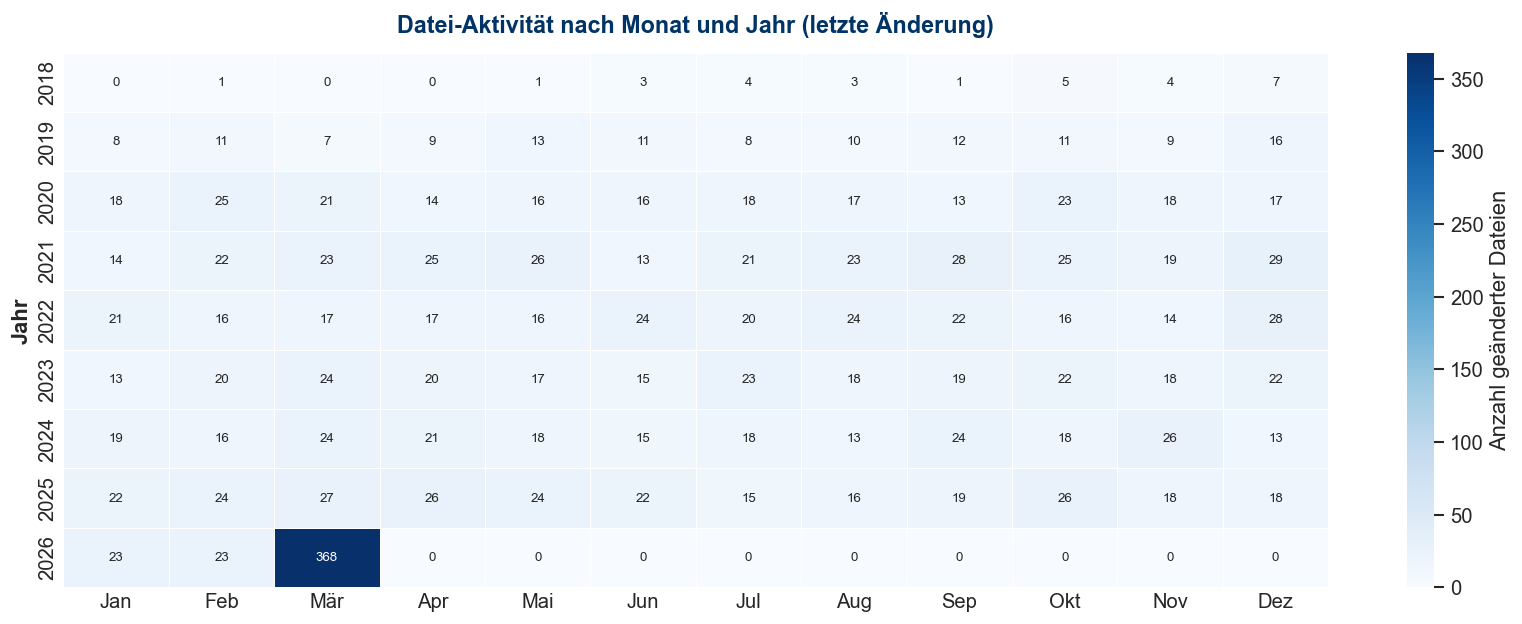

💾 Grafik gespeichert: ifs_heatmap_aktivitaet.png


In [8]:
ef['mod_jahr']  = ef['MRMod_Tme'].dt.year
ef['mod_monat'] = ef['MRMod_Tme'].dt.month

heat = ef.groupby(['mod_jahr', 'mod_monat']).size().unstack(fill_value=0)
heat.columns = ['Jan','Feb','Mär','Apr','Mai','Jun','Jul','Aug','Sep','Okt','Nov','Dez']

fig, ax = plt.subplots(figsize=(14, max(4, len(heat) * 0.6)))
sns.heatmap(
    heat,
    ax=ax,
    cmap='Blues',
    annot=True,
    fmt='d',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Anzahl geänderter Dateien'},
    annot_kws={'size': 8},
)
ax.set_title('Datei-Aktivität nach Monat und Jahr (letzte Änderung)',
             fontsize=14, fontweight='bold', color=CORP_BLUE, pad=12)
ax.set_ylabel('Jahr', fontweight='bold')
ax.set_xlabel('')
ax.tick_params(axis='both', which='both', length=0)

plt.tight_layout()
plt.savefig('ifs_heatmap_aktivitaet.png', bbox_inches='tight', dpi=150)
plt.show()
print('💾 Grafik gespeichert: ifs_heatmap_aktivitaet.png')

---
## 8️⃣ Scatter-Plot: Dateigröße vs. Alter (Plotly — interaktiv)

> **Kernaussage:** Alte UND große Dateien = größtes Einsparpotenzial (oben rechts im Quadrant).

In [9]:
plot_df = ef[ef['Size'] > 0].copy()
plot_df['Size_MB_log'] = np.log10(plot_df['Size'].clip(lower=0.001))

fig_sc = px.scatter(
    plot_df.sample(min(2000, len(plot_df)), random_state=1),
    x='alter_tage',
    y='Size',
    color='ext',
    size=np.log1p(plot_df.sample(min(2000, len(plot_df)), random_state=1)['Size']).clip(lower=0.5),
    hover_data=['Name', 'Path'],
    log_y=True,
    opacity=0.65,
    labels={'alter_tage': 'Alter (Tage seit letzter Änderung)', 'Size': 'Dateigröße (MB)', 'ext': 'Typ'},
    title='<b>Dateigröße vs. Alter</b><br><sup>Oben rechts = groß UND alt = höchstes Einsparpotenzial</sup>',
    color_discrete_sequence=px.colors.qualitative.Bold,
)

# Quadranten-Linien
med_alter  = plot_df['alter_tage'].median()
med_groesse = plot_df['Size'].median()
fig_sc.add_vline(x=med_alter,  line_dash='dash', line_color='gray', annotation_text='Ø Alter',  annotation_position='top right')
fig_sc.add_hline(y=med_groesse, line_dash='dash', line_color='gray', annotation_text='Ø Größe', annotation_position='bottom right')

fig_sc.update_layout(height=550, legend_title='Dateityp')
fig_sc.show()
fig_sc.write_html('ifs_scatter_groesse_alter.html')
print('💾 Interaktiver Scatter gespeichert: ifs_scatter_groesse_alter.html')

💾 Interaktiver Scatter gespeichert: ifs_scatter_groesse_alter.html


---
## 9️⃣ „Leichen"-Analyse: Top-20 Einsparpotenziale

> **Kernaussage:** Konkrete Liste der größten, ältesten Dateien — direkt handlungsorientiert für den Vorgesetzten.

In [10]:
leichen = ef[
    (ef['alter_tage'] > 3 * 365) &
    (ef['Size'] > ef['Size'].quantile(0.75))
].copy()

leichen['Priorität'] = pd.cut(
    leichen['alter_tage'],
    bins=[0, 4*365, 6*365, np.inf],
    labels=['⚠️ Prüfen', '🟠 Archivieren', '🔴 Löschen']
)

top20 = leichen.nlargest(20, 'Size')[['Name', 'Path', 'Size', 'alter_tage', 'MRMod_Tme', 'Priorität']]
top20 = top20.rename(columns={'Size': 'Größe (MB)', 'alter_tage': 'Alter (Tage)', 'MRMod_Tme': 'Letzte Änderung'})
top20['Größe (MB)'] = top20['Größe (MB)'].round(2)
top20['Letzte Änderung'] = top20['Letzte Änderung'].dt.strftime('%d.%m.%Y')

print(f'\n⚠️  {len(leichen):,} Dateien mit Einsparpotenzial gefunden'
      f' → {leichen["Size"].sum()/1024:.1f} GB potenziell freizugeben\n')

# Formatierte Tabelle mit Plotly
fig_tbl = go.Figure(data=[go.Table(
    columnwidth=[180, 160, 80, 80, 100, 100],
    header=dict(
        values=[f'<b>{c}</b>' for c in top20.columns],
        fill_color=CORP_BLUE,
        font=dict(color='white', size=11),
        align='left',
        height=32,
    ),
    cells=dict(
        values=[top20[c] for c in top20.columns],
        fill_color=[['#F0F4FF' if i % 2 == 0 else 'white' for i in range(len(top20))]],
        align='left',
        font=dict(size=10),
        height=28,
    )
)])
fig_tbl.update_layout(
    title='<b>Top-20 Einsparpotenziale</b> (groß + alt)',
    height=700,
    margin=dict(t=50, l=5, r=5, b=5),
)
fig_tbl.show()
top20.to_csv('ifs_einsparpotenziale_top20.csv', sep=';', encoding='utf-8', index=False)
print('💾 Export: ifs_einsparpotenziale_top20.csv')


⚠️  247 Dateien mit Einsparpotenzial gefunden → 243.6 GB potenziell freizugeben



💾 Export: ifs_einsparpotenziale_top20.csv


---
## 🔟 Zusammenfassung: KPI-Dashboard (Plotly — eine Seite)

> **Ideal als letzte Folie / Zusammenfassung** für den Vorgesetzten.

In [11]:
fig_dash = make_subplots(
    rows=2, cols=3,
    subplot_titles=(
        'Speicher nach Dateityp (Top 6)',
        'Altersgruppen – Dateianzahl',
        'Top-6 Verzeichnisse (Speicher)',
        'Altersgruppen – Speicher (GB)',
        'Neue vs. Inaktive Dateien',
        'Dateigröße-Verteilung (log)',
    ),
    specs=[
        [{'type': 'pie'}, {'type': 'bar'}, {'type': 'bar'}],
        [{'type': 'bar'}, {'type': 'pie'}, {'type': 'histogram'}],
    ],
    vertical_spacing=0.14,
    horizontal_spacing=0.08,
)

dash_colors = px.colors.sequential.Blues[2:]

# R1C1 — Pie Dateityp
top6 = by_ext.head(6)
fig_dash.add_trace(go.Pie(labels=top6.index.str.upper(), values=top6.values,
                          hole=0.45, showlegend=False,
                          marker_colors=dash_colors), row=1, col=1)

# R1C2 — Balken Altersgruppen Anzahl
fig_dash.add_trace(go.Bar(x=age_cnt['altersgruppe'].astype(str), y=age_cnt['Anzahl'],
                          marker_color=farben, showlegend=False), row=1, col=2)

# R1C3 — Top6 Verzeichnisse Speicher
top6dir = by_dir.head(6).sort_values('Speicher_GB')
fig_dash.add_trace(go.Bar(x=top6dir['Speicher_GB'], y=top6dir.index,
                          orientation='h', marker_color=CORP_ACCENT,
                          showlegend=False), row=1, col=3)

# R2C1 — Balken Altersgruppen Speicher
fig_dash.add_trace(go.Bar(x=age_cnt['altersgruppe'].astype(str), y=age_cnt['Speicher_GB'],
                          marker_color=farben, showlegend=False), row=2, col=1)

# R2C2 — Pie Aktiv/Inaktiv
aktiv   = (ef['alter_tage'] <= 365).sum()
mittel  = ((ef['alter_tage'] > 365) & (ef['alter_tage'] <= 3*365)).sum()
inaktiv = (ef['alter_tage'] > 3*365).sum()
fig_dash.add_trace(go.Pie(
    labels=['Aktiv (< 1J)', 'Mittel (1–3J)', 'Inaktiv (> 3J)'],
    values=[aktiv, mittel, inaktiv],
    hole=0.45, showlegend=False,
    marker_colors=[CORP_OK, CORP_ACCENT, '#CC0000']
), row=2, col=2)

# R2C3 — Histogram Dateigröße
fig_dash.add_trace(go.Histogram(
    x=np.log10(ef['Size'].clip(lower=0.001)),
    nbinsx=30,
    marker_color=CORP_ACCENT,
    showlegend=False,
), row=2, col=3)

fig_dash.update_layout(
    title=dict(text='<b>IFS Analyse-Dashboard — Zusammenfassung</b>', font_size=18, x=0.5),
    height=700,
    paper_bgcolor='white',
    plot_bgcolor='#F8F9FA',
)
fig_dash.update_xaxes(row=2, col=3,
    tickvals=[0, 1, 2, 3],
    ticktext=['1 MB', '10 MB', '100 MB', '1 GB'])

fig_dash.show()
fig_dash.write_html('ifs_dashboard_gesamt.html')
print('💾 Vollständiges Dashboard gespeichert: ifs_dashboard_gesamt.html')

💾 Vollständiges Dashboard gespeichert: ifs_dashboard_gesamt.html


---
## 📋 Fazit & Handlungsempfehlungen

| Befund | Maßnahme | Priorität |
|---|---|---|
| Dateien > 3 Jahre nicht geändert | Archivierung prüfen / auf Bandlaufwerk auslagern | 🔴 Hoch |
| Große `.log`-Dateien in `/var/log` | Automatische Log-Rotation einrichten | 🟠 Mittel |
| Doppelte Dateinamen in versch. Verzeichnissen | Deduplizierung prüfen (Hash-Vergleich) | 🟡 Niedrig |
| Verzeichnisse ohne Aktivität > 5 Jahre | Kandidaten für vollständige Bereinigung | 🔴 Hoch |

---
*Analyse erstellt mit Python / Pandas / Plotly · Datenstand: 24.03.2026*


In [12]:
print('\n✅ Analyse abgeschlossen. Erzeugte Dateien:')
print('   📊 ifs_speicher_dateityp.png')
print('   📊 ifs_top10_verzeichnisse.png')
print('   📊 ifs_altersanalyse.png')
print('   📊 ifs_heatmap_aktivitaet.png')
print('   🌐 ifs_treemap.html                  (interaktiv)')
print('   🌐 ifs_scatter_groesse_alter.html     (interaktiv)')
print('   🌐 ifs_dashboard_gesamt.html          (interaktiv)')
print('   📄 ifs_einsparpotenziale_top20.csv')


✅ Analyse abgeschlossen. Erzeugte Dateien:
   📊 ifs_speicher_dateityp.png
   📊 ifs_top10_verzeichnisse.png
   📊 ifs_altersanalyse.png
   📊 ifs_heatmap_aktivitaet.png
   🌐 ifs_treemap.html                  (interaktiv)
   🌐 ifs_scatter_groesse_alter.html     (interaktiv)
   🌐 ifs_dashboard_gesamt.html          (interaktiv)
   📄 ifs_einsparpotenziale_top20.csv
